In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 65.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=d8b276446471f53901ddf406fab1b1ebe6adcf359f1f36c09b98914095698003
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


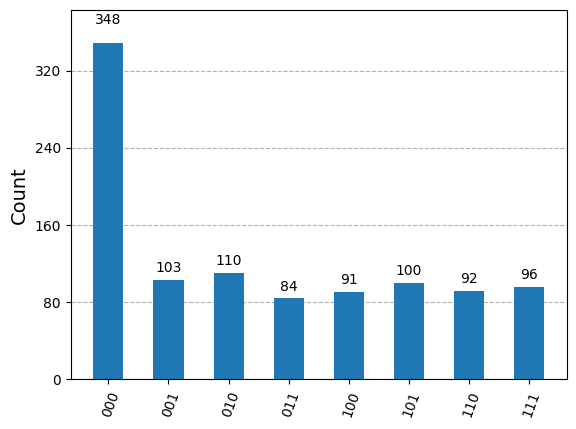

In [4]:
# Grover's algorithm
# Given a function f : {0,1}^n -> {0,1} such that for some input vector w,
# f(w) = 1 and for all x != w, f(x) = 0.
# The problem is to find w.

# Here we work with 3 qubits

# First we need a definition of f.

# Let's say f(0,0,0) = 1
# Try changing this to represent different search targets (you will need to change the definition of U, below)

# Then we need to define a unitary operator U on 3 qubits, such that
# U|x> = -|x> if f(x) = 1
# U|x> =  |x> if f(x) = 0

U = Operator([
   [-1, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1]
])

# Now construct the Grover diffusion operator

G_matrix = list(map(lambda x: list(map(lambda y: y/4.0,x)),[
    [-3,1, 1, 1, 1, 1, 1, 1],
    [1,-3, 1, 1, 1, 1, 1, 1],
    [1, 1,-3, 1, 1, 1, 1, 1],
    [1, 1, 1,-3, 1, 1, 1, 1],
    [1, 1, 1, 1,-3, 1, 1, 1],
    [1, 1, 1, 1, 1,-3, 1, 1],
    [1, 1, 1, 1, 1, 1,-3, 1],
    [1, 1, 1, 1, 1, 1, 1,-3]
]))

G = Operator(G_matrix)

# Build a circuit with the correct number of iterations hard-coded, in this case 2

grover = QuantumCircuit(3)

# To get the initial state, apply H to every qubit

grover.h(0)
grover.h(1)
grover.h(2)

# Repeatedly apply U then G

grover.append(U,[0,1,2])
grover.append(G,[0,1,2])
grover.append(U,[0,1,2])
grover.append(G,[0,1,2])

# What if we do too many iterations?

grover.append(U,[0,1,2])
grover.append(G,[0,1,2])

# Measure all the qubits - to do that, we don't need to introduce classical bits

grover.measure_all()

# Simulate and plot results

backend = BasicSimulator()
compiled = transpile(grover, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
plot_histogram(counts)

In [6]:
# This is a classic phenomenon in quantum computing called over-rotation.In Grover's Algorithm, the probability of finding the correct answer doesn't just keep increasing with more iterations; it actually behaves like a wave (a sine function). If you perform too many iterations, you "overshoot" the peak probability and start rotating back toward the other states.1. Why the first graph was betterFor a 3-qubit system ($N=8$), the optimal number of iterations is roughly $\frac{\pi}{4}\sqrt{N} \approx 2.22$.At 2 iterations: You were almost at the peak of the wave. The probability of measuring $|000\rangle$ is mathematically expected to be about 94.5%. Your first graph (image_55f339.png) reflects this perfectly with 980 counts out of 1024.2. Why the second graph changedBy adding that 3rd iteration, you pushed the quantum state past the "target" and began rotating it away from $|000\rangle$.At 3 iterations: The probability of finding the correct answer actually drops to about 33%.In your second graph (image_55f319.png), the count for 000 is 348, which is almost exactly $1024 \times 0.33$. The remaining probability is spread across the other "wrong" states, which is why the other bars grew significantly taller.Summary of the "Issue"The "issue" isn't a bug in your code; it's a fundamental property of the algorithm. Grover's algorithm performs a geometric rotation in a high-dimensional space.2 Iterations: The rotation stops right in front of the target.3 Iterations: The rotation continues past the target, making the target state less likely to be measured than it was before.If you were to add even more iterations (say, 4 or 5), you would eventually see the probability of $|000\rangle$ rise back up again as the rotation completes a full circle.